In [2]:
import pandas as pd
import os
import psycopg2
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

load_dotenv()

True

# Items

In [7]:
items = pd.read_parquet("/home/kirill/AI2026/thesis/data/ml_ozon_recsys_train_final_apparel_items_data/ml_ozon_recsys_train_final_apparel_items_data/part-00099-5322ad28-d73d-4c69-86d2-4efc7ad4f422-c000.snappy.parquet")

In [ ]:
items.head()

,item_id,itemname,attributes,fclip_embed,catalogid,variant_id,model_id
0,160781,"Колготки Ot zaycev романтическое настроение, 4...","[{'attribute_name': 'Type', 'attribute_value':...","[-0.081578024, 0.16095915, -0.09692034, 0.0441...",36470,81114351,26014216
1,344256,Сандалии Baden,"[{'attribute_name': 'Name', 'attribute_value':...","[0.043452144, -0.6318996, 0.06702036, 0.499945...",7645,183463491,11013745
2,919418,Футболка ТВОЕ,"[{'attribute_name': 'Type', 'attribute_value':...","[0.030272983, 0.51682675, 0.275845, -0.0225585...",7508,332842238,37110023
3,1105301,Футболка Zerosell,"[{'attribute_name': 'Type', 'attribute_value':...","[0.12174834, 0.08045447, -0.6046851, 0.2336127...",36745,75094238,15505352
4,1395200,Платье,"[{'attribute_name': 'Type', 'attribute_value':...","[0.092158556, 1.4629544, -0.33898428, 0.636307...",7502,323128318,42644445
...,...,...,...,...,...,...,...
64473,338419519,Платье MSFILIA,"[{'attribute_name': 'Type', 'attribute_value':...","[-0.26745975, 2.14681, 0.2772807, -0.36375648,...",7502,193375253,24017719
64474,338424855,Солнцезащитные очки Gucci,"[{'attribute_name': 'Type', 'attribute_value':...","[0.23326689, -1.5168123, -0.37452206, 0.244134...",17019,123682702,23949519
64475,338477493,Платок шейный Olie Two,"[{'attribute_name': 'Type', 'attribute_value':...","[-0.59744775, 1.0821954, -1.1280422, -0.069102...",17055,59155134,38020536
64476,338517136,Плащ Zolla,"[{'attribute_name': 'Type', 'attribute_value':...","[-0.123741046, 0.51597476, 0.3291093, 0.322233...",7532,266814610,521029


# Orders


In [121]:
orders = pd.read_parquet("/home/kirill/AI2026/thesis/data/ml_ozon_recsys_train_final_apparel_orders_data/ml_ozon_recsys_train_final_apparel_orders_data/part-00003-7b718cf5-560c-4ace-bbb7-e36ef433637b-c000.snappy.parquet")

In [122]:
orders.head()

,item_id,user_id,created_timestamp,last_status,last_status_timestamp,created_date
0,17809,1722851,2025-03-21 10:27:06.073,delivered_orders,2025-03-27 19:17:16,2025-03-21
1,39971,1213620,2025-03-22 20:53:16.313,canceled_orders,2025-03-31 13:04:31,2025-03-22
2,39971,4871250,2025-03-20 04:23:00.906,canceled_orders,2025-03-29 18:35:30,2025-03-20
3,39971,4804470,2025-05-05 15:07:29.756,canceled_orders,2025-05-09 01:35:52,2025-05-05
4,39971,2747690,2025-04-09 03:57:44.636,canceled_orders,2025-04-17 19:21:03,2025-04-09


In [123]:
print(orders['created_date'].min())
print(orders['created_date'].max())

2025-01-01
2025-07-01


# Tracker

In [119]:
tracker = pd.read_parquet("/home/kirill/AI2026/thesis/data/ml_ozon_recsys_train_final_apparel_tracker_data/ml_ozon_recsys_train_final_apparel_tracker_data/part-00005-582d88ee-8dd6-41f6-9f90-375910468cb7-c000.snappy.parquet")

In [120]:
tracker.head()

,item_id,user_id,timestamp,action_type,action_widget,date
0,447447,2225130,2025-02-11 10:57:06,page_view,catalog.searchResultsV2,2025-02-11
1,447447,2225130,2025-02-11 10:56:59,page_view,catalog.searchResultsV2,2025-02-11
2,447447,1511741,2025-02-11 18:59:22,page_view,cart.split,2025-02-11
3,447447,2848800,2025-01-14 12:44:46,page_view,catalog.searchResultsV2,2025-01-14
4,447447,2011350,2025-01-14 15:07:59,page_view,catalog.searchResultsV2,2025-01-14


# Category

In [ ]:
category = pd.read_parquet("/home/kirill/AI2026/thesis/data/ml_ozon_recsys_train_final_categories_tree/ml_ozon_recsys_train_final_categories_tree/part-00000-163f9108-23d6-4fd6-98c4-7bcb73ee27e2-c000.snappy.parquet")

In [7]:
category.head()

,catalogid,catalogpath,ids
0,15500,"[{'id': 15500, 'name': 'Электроника', 'fullNam...","[15500, -1]"
1,15501,"[{'id': 15501, 'name': 'Телефоны и смарт-часы'...","[15501, 15500, -1]"
2,15502,"[{'id': 15502, 'name': 'Смартфоны', 'fullName'...","[15502, 15501, 15500, -1]"
3,15511,"[{'id': 15511, 'name': 'Аксессуары для смартфо...","[15511, 15501, 15500, -1]"
4,15892,"[{'id': 15892, 'name': 'Чехлы', 'fullName': 'Ч...","[15892, 15511, 15501, 15500, -1]"


In [17]:
category['ids'].apply(lambda x: x.tolist())

0                            [15500, -1]
1                     [15501, 15500, -1]
2              [15502, 15501, 15500, -1]
3              [15511, 15501, 15500, -1]
4       [15892, 15511, 15501, 15500, -1]
                      ...               
7007           [39405, 55455, 55055, -1]
7008           [39406, 55455, 55055, -1]
7009                  [39398, 55055, -1]
7010                  [39792, 55055, -1]
7011                         [77777, -1]
Name: ids, Length: 7012, dtype: object

In [3]:
PG_URL = os.getenv("POSTGRES_URL")
SCHEMA = os.getenv("POSTGRES_SCHEMA")

def get_conn():
    return psycopg2.connect(PG_URL)
def pg_sql(sql):
    conn = get_conn()
    try:
        cur = conn.cursor()
        cur.execute(sql)
        rows = cur.fetchall()
        cur.close()
        conn.close()
    except e:
        print("Error:", e)
        conn.close()
    return rows

In [26]:
data = pg_sql("""
SELECT 
    'orders'  AS tbl,
    COUNT(*) AS n_rows,
    COUNT(DISTINCT item_id) AS uniq_items,
    COUNT(DISTINCT user_id) AS uniq_users,
    MIN(created_date)::TEXT AS dt_from,
    MAX(created_date)::TEXT AS dt_to,
    NULL::BIGINT AS uniq_catalogid
FROM seller.orders
UNION ALL
SELECT
    'tracker', 
    COUNT(*),
    COUNT(DISTINCT item_id),
    COUNT(DISTINCT user_id),
    MIN(date)::TEXT,
    MAX(date)::TEXT,
    NULL::BIGINT
FROM seller.tracker
UNION ALL
SELECT 
    'items',
    COUNT(*),
    COUNT(DISTINCT item_id),
    NULL,
    NULL,
    NULL,
    COUNT(DISTINCT catalogid)
FROM seller.items
UNION ALL
SELECT
    'category',
    COUNT(*),
    NULL,
    NULL,
    NULL,
    NULL,
    COUNT(DISTINCT catalogid)
FROM seller.category;
""")
df_high_level = pd.DataFrame(data, columns=['tbl', 'n_rows', 'uniq_items', 'uniq_users', 'dt_from', 'dt_to', 'uniq_catalogid'])
df_high_level

,tbl,n_rows,uniq_items,uniq_users,dt_from,dt_to,uniq_catalogid
0,orders,18887122,4673763.0,834137.0,2025-01-01,2025-07-01,NaN
1,tracker,764621264,2277734.0,1006345.0,2025-01-01,2025-07-01,NaN
2,items,6439422,6342024.0,NaN,None,None,478.0
3,category,7012,NaN,NaN,None,None,7012.0


In [28]:
data = pg_sql("""
SELECT
    COUNT(*)                                    AS total_orders,
    COUNT(i.item_id)                            AS with_item,
    COUNT(c.catalogid)                          AS with_category,
    ROUND(100.0*COUNT(i.item_id)/COUNT(*), 2)  AS pct_item_match,
    ROUND(100.0*COUNT(c.catalogid)/COUNT(*),2) AS pct_cat_match
FROM seller.orders o
LEFT JOIN seller.items i ON o.item_id = i.item_id
LEFT JOIN seller.category c ON i.catalogid = c.catalogid;
""")

df_linkage_quality = pd.DataFrame(data, columns=['total_orders', 'with_item', 'with_category', 'pct_item_match', 'pct_cat_match'])
df_linkage_quality

,total_orders,with_item,with_category,pct_item_match,pct_cat_match
0,18887590,18887590,18887590,100.00,100.00


In [29]:
data = pg_sql("""
SELECT last_status,
       COUNT(*) AS cnt,
       ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER(), 2) AS pct
FROM seller.orders
GROUP BY last_status
ORDER BY cnt DESC;
""")

df_order_status_dist = pd.DataFrame(data, columns=['last_status', 'cnt', 'pct'])
df_order_status_dist

,last_status,cnt,pct
0,delivered_orders,9936249,52.61
1,canceled_orders,7990577,42.31
2,proccesed_orders,960296,5.08


In [30]:
data = pg_sql("""
SELECT action_type,
       COUNT(*) AS cnt,
       ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER(), 2) AS pct,
       COUNT(DISTINCT action_widget) AS uniq_widgets
FROM seller.tracker
GROUP BY action_type
ORDER BY cnt DESC;
""")

df_tracker_action_taxonomy = pd.DataFrame(data, columns=['action_type', 'cnt', 'pct', 'uniq_widgets'])
df_tracker_action_taxonomy

,action_type,cnt,pct,uniq_widgets
0,page_view,546922594,71.53,78
1,view_description,103154397,13.49,6
2,review_view,35557086,4.65,2
3,to_cart,28358574,3.71,50
4,favorite,24140344,3.16,91
5,remove,17280223,2.26,41
6,unfavorite,9208046,1.20,50


In [31]:
data = pg_sql("""
WITH parsed AS (
    SELECT catalogid,
           jsonb_array_length(catalogpath) AS depth,
           catalogpath->0->>'name' AS leaf_cat,
           catalogpath->(jsonb_array_length(catalogpath)-1)->>'name' AS root_cat,
           catalogpath->(jsonb_array_length(catalogpath)-2)->>'name' AS level1_cat
    FROM seller.category
)
SELECT
    level1_cat,
    depth,
    COUNT(*) AS n_items
FROM parsed
GROUP BY level1_cat, depth
ORDER BY n_items DESC
LIMIT 30;
""")

df_category_hierarchy = pd.DataFrame(data, columns=['catalogid', 'depth', 'leaf_cat', 'root_cat', 'level1_cat'])
df_category_hierarchy

NameError: name 'e' is not defined

In [32]:
data = pg_sql("""
WITH views AS (
    SELECT item_id, user_id, date
    FROM seller.tracker
    WHERE action_type = 'page_view'
),
carts AS (
    SELECT item_id, user_id, date
    FROM seller.tracker
    WHERE action_type = 'to_cart'
),
ords AS (
    SELECT item_id, user_id, created_date AS date
    FROM seller.orders
)
SELECT
    COUNT(DISTINCT v.user_id) AS viewers,
    COUNT(DISTINCT c.user_id) AS add_to_carters,
    COUNT(DISTINCT o.user_id) AS buyers,
    ROUND(100.0*COUNT(DISTINCT c.user_id)/NULLIF(COUNT(DISTINCT v.user_id),0), 2) AS view_to_cart_pct,
    ROUND(100.0*COUNT(DISTINCT o.user_id)/NULLIF(COUNT(DISTINCT v.user_id),0), 2) AS view_to_order_pct
FROM views v
LEFT JOIN carts c
    ON v.user_id = c.user_id AND v.item_id = c.item_id AND v.date = c.date
LEFT JOIN ords o
    ON v.user_id = o.user_id AND v.item_id = o.item_id AND v.date = o.date;
""")

df_same_day_funnel = pd.DataFrame(data, columns=['viewers', 'add_to_carters', 'buyers', 'view_to_cart_pct', 'view_to_order_pct'])
df_same_day_funnel

,viewers,add_to_carters,buyers,view_to_cart_pct,view_to_order_pct
0,1005484,890369,744729,88.55,74.07


## Clickhouse

In [57]:
import clickhouse_connect

CLICKHOUSE_HOST = os.getenv("CLICKHOUSE_HOST")
CLICKHOUSE_HTTP_PORT = os.getenv("CLICKHOUSE_HTTP_PORT")
CLICKHOUSE_USER = os.getenv("CLICKHOUSE_USER")
CLICKHOUSE_PASSWORD = os.getenv("CLICKHOUSE_PASSWORD")
CLICKHOUSE_DB = os.getenv("CLICKHOUSE_DB")

def get_conn_click():
    client = clickhouse_connect.get_client(
        host='localhost',
        port=CLICKHOUSE_HTTP_PORT,
        username=CLICKHOUSE_USER,
        password=CLICKHOUSE_PASSWORD
    )
    return client


def click_sql(sql):
    client = get_conn_click()
    try:
        result = client.query(sql)
        client.close()
        return result.result_rows
    except Exception as e:
        print("Error:", e)
        client.close()

In [56]:
data = click_sql("""
SELECT
    date,
    sum(orders_cnt)                          AS orders,
    sum(users_cnt)                           AS unique_users,
    sum(views_cnt)                           AS views,
    round(divide(sum(orders_cnt), sum(views_cnt)), 4) AS conv_rate,
    uniq(item_id)                   AS active_items
FROM analytics.item_daily_stats
GROUP BY date
ORDER BY date
""")

df_global_daily = pd.DataFrame(data, columns=['date', 'orders', 'unique_users', 'views', 'conv_rate', 'active_items'])
df_global_daily

,date,orders,unique_users,views,conv_rate,active_items
0,2025-01-01,149149,145673,4564273,0.0327,721238
1,2025-01-02,101442,99494,3183728,0.0319,632727
2,2025-01-03,88187,86380,2898862,0.0304,607977
3,2025-01-04,84578,82920,2836125,0.0298,603368
4,2025-01-05,83759,82045,2797229,0.0299,599785
...,...,...,...,...,...,...
177,2025-06-27,119440,116474,2828572,0.0422,680470
178,2025-06-28,111752,108655,2853696,0.0392,681515
179,2025-06-29,116491,114178,3059180,0.0381,703874
180,2025-06-30,120162,116892,2937837,0.0409,688371


In [124]:
data = click_sql("""
SELECT
    toDayOfWeek(date) AS dow,
    toMonth(date)     AS month,
    sum(orders_cnt) / countDistinct(date) AS avg_daily_orders,
    sum(views_cnt)  / countDistinct(date) AS avg_daily_views
FROM analytics.item_daily_stats
GROUP BY dow, month
ORDER BY dow, month
""")

df_day_month_seasonality = pd.DataFrame(data, columns=['dow', 'month', 'avg_daily_orders', 'avg_daily_views'])
df_day_month_seasonality.head(10)

,dow,month,avg_daily_orders,avg_daily_views
0,1,1,70401.75,2446643.00
1,1,2,80620.50,1990835.75
2,1,3,101966.20,3092331.60
3,1,4,105347.25,3152333.25
4,1,5,118233.50,3138345.00
5,1,6,120875.40,3061690.40
6,2,1,70060.75,2459081.50
7,2,2,75631.25,2514456.75
8,2,3,94142.50,2970745.75
9,2,4,103797.00,3087502.40


,hr,orders,canceled,cancel_pct,uniq_users
0,0,93953,43671,46.48,58133
1,1,56514,25571,45.25,35654
2,2,39210,17107,43.63,25133
3,3,34306,14462,42.16,22415
4,4,39682,16371,41.26,26361
5,5,54899,22389,40.78,36450
6,6,84385,35412,41.96,55695
7,7,121496,51219,42.16,79459
8,8,162547,68969,42.43,104009
9,9,194055,81571,42.03,123029


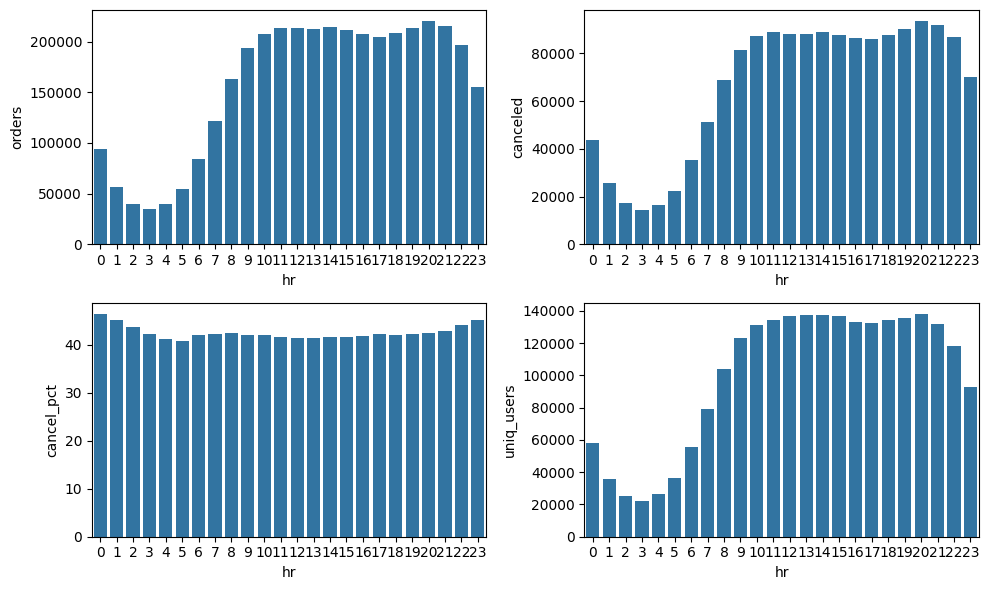

In [101]:
data = click_sql("""
SELECT
    toHour(created_hour) AS hr,
    count()              AS orders,
    sum(is_canceled)     AS canceled,
    round(100.0 * sum(is_canceled) / count(), 2) AS cancel_pct,
    uniq(user_id) AS uniq_users
FROM analytics.order_facts
GROUP BY hr
ORDER BY hr
""")

df_hour_pattern = pd.DataFrame(data, columns=['hr', 'orders', 'canceled', 'cancel_pct', 'uniq_users'])
display(df_hour_pattern.head(10))

fig, ax = plt.subplots(2, 2, figsize=(10, 6))
sns.barplot(df_hour_pattern, x='hr', y='orders', ax=ax[0][0])
sns.barplot(df_hour_pattern, x='hr', y='canceled', ax=ax[0][1])
sns.barplot(df_hour_pattern, x='hr', y='cancel_pct', ax=ax[1][0])
sns.barplot(df_hour_pattern, x='hr', y='uniq_users', ax=ax[1][1])
fig.tight_layout()

In [102]:
data = click_sql("""
SELECT
    activity_class,
    count()    AS n_items,
    sum(total_orders) AS cum_orders,
    sum(total_views)  AS cum_views
FROM (
    SELECT
        item_id,
        sum(orders_cnt) AS total_orders,
        sum(views_cnt)  AS total_views,
        multiIf(
            sum(orders_cnt) = 0,  '0_orders',
            sum(orders_cnt) <= 5, '1-5_orders',
            sum(orders_cnt) <= 20,'6-20_orders',
            sum(orders_cnt) <= 100,'21-100_orders',
            '100+_orders'
        ) AS activity_class
    FROM analytics.item_daily_stats
    GROUP BY item_id
)
GROUP BY activity_class
ORDER BY n_items
""")

df_activity_dist = pd.DataFrame(data, columns=['activity_class', 'n_items', 'cum_orders', 'cum_views'])
df_activity_dist

,activity_class,n_items,cum_orders,cum_views
0,100+_orders,6446,1338841,19079378
1,0_orders,102155,0,2253823
2,21-100_orders,111293,3960873,89915798
3,6-20_orders,649919,6344446,179098903
4,1-5_orders,3906105,7243430,256580500


In [104]:
data = click_sql("""
SELECT
    item_id,
    count()                                 AS n_days,
    countIf(orders_cnt > 0)                 AS active_days,
    round(100.0 * active_days / n_days, 1)  AS activity_rate,
    sum(orders_cnt)                         AS total_orders,
    stddevSamp(orders_cnt)                  AS std_orders
FROM analytics.item_daily_stats
GROUP BY item_id
HAVING n_days >= 30          -- need at least 30 days of history
ORDER BY activity_rate DESC, total_orders DESC
LIMIT 50
""")

df_forecastability = pd.DataFrame(data, columns=['item_id', 'n_days', 'active_days', 'activity_rate', 'total_orders', 'std_orders'])
df_forecastability

,item_id,n_days,active_days,activity_rate,total_orders,std_orders
0,51974017,182,182,100.0,12604,19.071308
1,187052809,182,182,100.0,11840,34.195203
2,207631139,157,157,100.0,8548,53.683712
3,247423473,92,92,100.0,2755,16.100894
4,201930716,180,180,100.0,2282,8.243267
5,287588242,182,182,100.0,2206,9.240596
6,7253950,178,178,100.0,2184,7.655380
7,34669933,182,182,100.0,2124,9.795201
8,273122456,181,181,100.0,2033,5.096978
9,152349005,138,138,100.0,2028,10.187733


In [58]:
data = click_sql("""
SELECT
    category_level1,
    countDistinct(item_id) AS items_with_orders,
    count()                AS orders,
    sum(is_canceled)       AS canceled,
    round(100.0 * sum(is_canceled) / count(), 2) AS cancel_rate,
    countDistinct(user_id) AS uniq_users
FROM analytics.order_facts
WHERE category_level1 != ''
GROUP BY category_level1
ORDER BY orders DESC
LIMIT 25
""")

df_catergory_performance = pd.DataFrame(data, columns=['category_level1', 'items_with_orders', 'orders', 'canceled', 'cancel_rate', 'uniq_users'])
df_catergory_performance

,category_level1,items_with_orders,orders,canceled,cancel_rate,uniq_users
0,Одежда,2986395,12139753,5510237,45.39,721581
1,Обувь,974964,3238464,1604136,49.53,548449
2,Аксессуары,660458,3201160,761356,23.78,614948
3,Ozon fresh,39379,245589,98620,40.16,137542
4,Спорт и отдых,7753,35609,12012,33.73,27898
5,"Туризм, рыбалка, охота",1725,9372,2047,21.84,7214
6,Детские товары,1360,7430,1211,16.30,4841
7,Аптека,609,5167,412,7.97,4418
8,Дом и сад,1117,5026,689,13.71,4256
9,Бытовая техника,1,10,7,70.00,10


In [108]:
data = click_sql("""
SELECT
    ids.category_path,
    sum(ids.views_cnt)  AS views,
    sum(ids.orders_cnt) AS orders,
    round(divide(sum(ids.orders_cnt), sum(ids.views_cnt)), 4) AS conv_rate,
    uniq(ids.item_id) AS items
FROM analytics.item_daily_stats ids
WHERE ids.category_path != ''
GROUP BY ids.category_path
ORDER BY views DESC
LIMIT 25
""")

df_category_funnel = pd.DataFrame(data, columns=['category_path', 'views', 'orders', 'conv_rate', 'items'])
df_category_funnel

,category_path,views,orders,conv_rate,items
0,"""[{\""id\"": 7502, \""name\"": \""Платья и сарафаны...",28279926,600005,0.0212,161905
1,"""[{\""id\"": 36484, \""name\"": \""Кроссовки и кеды...",18325944,487366,0.0266,157907
2,"""[{\""id\"": 7512, \""name\"": \""Брюки, бриджи и к...",15785138,521260,0.0330,107498
3,"""[{\""id\"": 7508, \""name\"": \""Футболки и поло\""...",14590004,593868,0.0407,122344
4,"""[{\""id\"": 17002, \""name\"": \""Сумки\"", \""fullN...",14238081,283087,0.0199,66316
5,"""[{\""id\"": 7530, \""name\"": \""Куртки и пуховики...",13915648,291613,0.0210,93297
6,"""[{\""id\"": 7511, \""name\"": \""Блузы и рубашки\""...",12443147,351805,0.0283,84292
7,"""[{\""id\"": 7660, \""name\"": \""Кеды, кроссовки и...",11401897,331449,0.0291,135165
8,"""[{\""id\"": 31306, \""name\"": \""Трусы\"", \""fullN...",9943617,355116,0.0357,61090
9,"""[{\""id\"": 7644, \""name\"": \""Туфли и балетки\""...",9745229,275352,0.0283,91662


In [117]:
data = click_sql("""
WITH first_order AS (
    SELECT user_id, min(created_date) AS first_date
    FROM analytics.order_facts
    GROUP BY user_id
)
SELECT
    of.created_date,
    countIf(fo.first_date = of.created_date) AS new_users,
    countIf(fo.first_date < of.created_date) AS returning_users,
    count()                                   AS total_orders
FROM analytics.order_facts of
JOIN first_order fo ON of.user_id = fo.user_id
GROUP BY of.created_date
ORDER BY of.created_date
""")

df_buyers = pd.DataFrame(data, columns=['created_date', 'new_users', 'returning_users', 'total_orders'])
df_buyers

,created_date,new_users,returning_users,total_orders
0,2025-01-01,29774,0,29774
1,2025-01-02,18882,1532,20414
2,2025-01-03,15185,2453,17638
3,2025-01-04,13887,3014,16901
4,2025-01-05,12983,3923,16906
...,...,...,...,...
177,2025-06-27,1349,22622,23971
178,2025-06-28,1338,20975,22313
179,2025-06-29,1493,21880,23373
180,2025-06-30,1447,22712,24159


In [118]:
data = click_sql("""
SELECT
    item_id,
    min(date) AS first_seen,
    max(date) AS last_seen,
    date_diff('day', min(date), max(date)) AS lifespan_days,
    sum(orders_cnt) AS total_orders,
    argMax(category_path, date) AS latest_category
FROM analytics.item_daily_stats
GROUP BY item_id
HAVING max(date) < today() - 7
ORDER BY total_orders DESC
LIMIT 30
""")

df_items_signals = pd.DataFrame(data, columns=['item_id', 'first_seen', 'last_seen', 'lifespan_days', 'total_orders', 'latest_category'])
df_items_signals

,item_id,first_seen,last_seen,lifespan_days,total_orders,latest_category
0,51974017,2025-01-01,2025-07-01,181,12604,"""[{\""id\"": 7813, \""name\"": \""Средства для уход..."
1,187052809,2025-01-01,2025-07-01,181,11840,"""[{\""id\"": 7771, \""name\"": \""Губки и щетки\"", ..."
2,207631139,2025-01-01,2025-07-01,181,8548,"""[{\""id\"": 36471, \""name\"": \""Носки\"", \""fullN..."
3,143497612,2025-01-01,2025-07-01,181,3983,"""[{\""id\"": 7813, \""name\"": \""Средства для уход..."
4,119105606,2025-01-01,2025-07-01,181,3262,"""[{\""id\"": 39418, \""name\"": \""Зонты\"", \""fullN..."
5,247423473,2025-04-01,2025-07-01,91,2755,"""[{\""id\"": 14629, \""name\"": \""Косметика и чист..."
6,285009143,2025-01-01,2025-07-01,181,2609,"""[{\""id\"": 7773, \""name\"": \""Шнурки\"", \""fullN..."
7,77696741,2025-01-01,2025-07-01,181,2607,"""[{\""id\"": 32992, \""name\"": \""Аксессуары\"", \""..."
8,263577203,2025-01-02,2025-07-01,180,2486,"""[{\""id\"": 14629, \""name\"": \""Косметика и чист..."
9,115793089,2025-03-04,2025-07-01,119,2292,"""[{\""id\"": 17048, \""name\"": \""Заколки, гребни ..."
